In [40]:
import pandas as pd
from google_play_scraper import Sort, reviews_all,reviews
import re
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
# Define bank app IDs
banks = {
    "CBE": "com.combanketh.mobilebanking",
    "BOA": "com.boa.boaMobileBanking",
    "Dashen": "com.dashen.dashensuperapp"
}

In [42]:
# Initialize a list to hold all reviews
all_reviews = []

# Scrape reviews for each bank
for bank_name, app_id in banks.items():
    reviews = reviews_all(app_id, sort=Sort.NEWEST, count=400)
    for review in reviews:
        all_reviews.append({
            'review': review['content'],
            'rating': review['score'],
            'date': review['at'],
            'bank': bank_name,
            'source': 'Google Play Store'
        })

# Convert to DataFrame
df = pd.DataFrame(all_reviews)

In [43]:
df

,review,rating,date,bank,source
0,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06 09:54:11,CBE,Google Play Store
1,what is this app problem???,1,2025-06-05 22:16:56,CBE,Google Play Store
2,the app is proactive and a good connections.,5,2025-06-05 15:55:10,CBE,Google Play Store
3,I cannot send to cbebirr app. through this app.,3,2025-06-05 11:12:49,CBE,Google Play Store
4,good,4,2025-06-05 10:21:59,CBE,Google Play Store
...,...,...,...,...,...
8986,Best,5,2025-01-13 21:11:58,Dashen,Google Play Store
8987,"Waw Great and innovated,user friendly, always ...",5,2025-01-13 21:01:12,Dashen,Google Play Store
8988,It's Best waww 🙏,5,2025-01-13 09:37:19,Dashen,Google Play Store
8989,Always one step ahead,5,2025-01-13 09:15:03,Dashen,Google Play Store


In [44]:
df.drop_duplicates(subset=['review'], inplace=True)

In [45]:
# Handle missing data
df.dropna(subset=['review', 'rating', 'date'], inplace=True)

In [46]:
df['date'] = pd.to_datetime(df['date'], unit='ms').dt.strftime('%Y-%m-%d')

In [47]:
df

,review,rating,date,bank,source
0,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06,CBE,Google Play Store
1,what is this app problem???,1,2025-06-05,CBE,Google Play Store
2,the app is proactive and a good connections.,5,2025-06-05,CBE,Google Play Store
3,I cannot send to cbebirr app. through this app.,3,2025-06-05,CBE,Google Play Store
4,good,4,2025-06-05,CBE,Google Play Store
...,...,...,...,...,...
8985,Faster and userfriendly,5,2025-01-14,Dashen,Google Play Store
8987,"Waw Great and innovated,user friendly, always ...",5,2025-01-13,Dashen,Google Play Store
8988,It's Best waww 🙏,5,2025-01-13,Dashen,Google Play Store
8989,Always one step ahead,5,2025-01-13,Dashen,Google Play Store


/tmp/ipykernel_53402/2184393256.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comment_counts, x='Bank', y='Comment Count', palette='viridis')


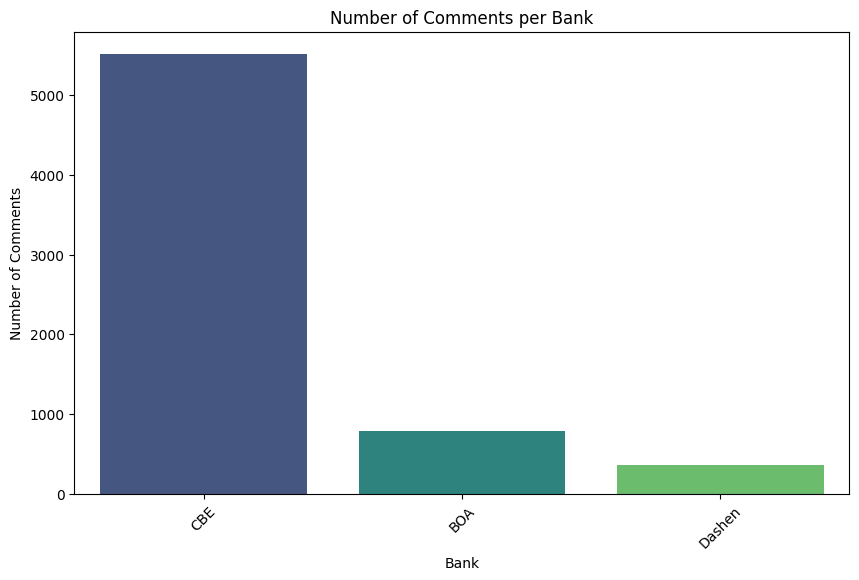

In [23]:
# Count the number of comments per bank
comment_counts = df['bank'].value_counts().reset_index()
comment_counts.columns = ['Bank', 'Comment Count']

# Plot the number of comments per bank
plt.figure(figsize=(10, 6))
sns.barplot(data=comment_counts, x='Bank', y='Comment Count', palette='viridis')
plt.title('Number of Comments per Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.savefig('comments_per_bank.png')
plt.show()

In [12]:
df.to_csv('bank_reviews.csv', index=False)

In [24]:
print(f"Total reviews collected: {len(df)}")
print(f"Missing data percentage: {df.isnull().mean().max() * 100:.2f}%")

Total reviews collected: 6669
Missing data percentage: 0.00%


In [14]:
from textblob import TextBlob
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
df = pd.read_csv('bank_reviews.csv')

In [16]:
df

,review,rating,date,bank,source
0,what is this app problem???,1,2025-06-05,CBE,Google Play Store
1,the app is proactive and a good connections.,5,2025-06-05,CBE,Google Play Store
2,I cannot send to cbebirr app. through this app.,3,2025-06-05,CBE,Google Play Store
3,good,4,2025-06-05,CBE,Google Play Store
4,not functional,1,2025-06-05,CBE,Google Play Store
...,...,...,...,...,...
6664,Faster and userfriendly,5,2025-01-14,Dashen,Google Play Store
6665,"Waw Great and innovated,user friendly, always ...",5,2025-01-13,Dashen,Google Play Store
6666,It's Best waww 🙏,5,2025-01-13,Dashen,Google Play Store
6667,Always one step ahead,5,2025-01-13,Dashen,Google Play Store


In [17]:
from transformers import pipeline
# Load sentiment analysis model
sentiment_pipeline = pipeline("sentiment-analysis")

/home/g/10/Week2/Customer-Experience-Analytics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [18]:
# Analyze sentiment
def analyze_sentiment(reviews):
    sentiments = sentiment_pipeline(reviews)
    return [sent['label'] for sent in sentiments]

# Apply sentiment analysis
df['sentiment'] = analyze_sentiment(df['review'].tolist())

# Save results
df.to_csv('bank_reviews_with_sentiment.csv', index=False)

In [19]:
df

,review,rating,date,bank,source,sentiment
0,what is this app problem???,1,2025-06-05,CBE,Google Play Store,NEGATIVE
1,the app is proactive and a good connections.,5,2025-06-05,CBE,Google Play Store,POSITIVE
2,I cannot send to cbebirr app. through this app.,3,2025-06-05,CBE,Google Play Store,NEGATIVE
3,good,4,2025-06-05,CBE,Google Play Store,POSITIVE
4,not functional,1,2025-06-05,CBE,Google Play Store,NEGATIVE
...,...,...,...,...,...,...
6664,Faster and userfriendly,5,2025-01-14,Dashen,Google Play Store,POSITIVE
6665,"Waw Great and innovated,user friendly, always ...",5,2025-01-13,Dashen,Google Play Store,POSITIVE
6666,It's Best waww 🙏,5,2025-01-13,Dashen,Google Play Store,POSITIVE
6667,Always one step ahead,5,2025-01-13,Dashen,Google Play Store,POSITIVE


In [21]:
sentiment_counts = df['sentiment'].value_counts()

/tmp/ipykernel_9320/2233136997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


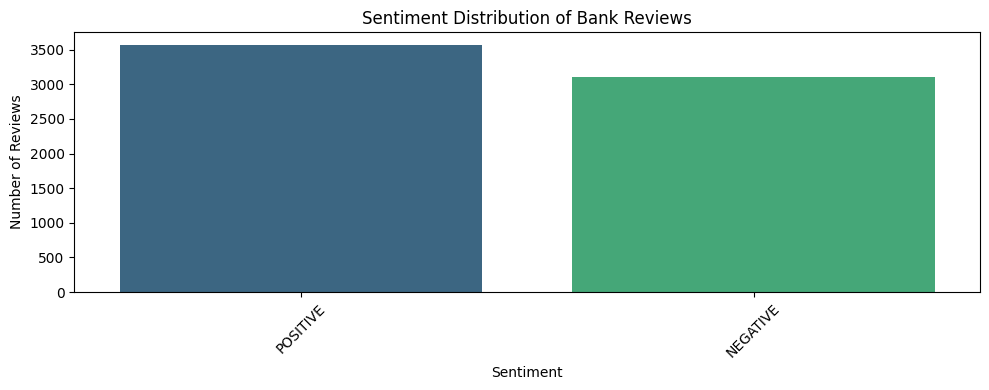

In [27]:
# Set up the plot
plt.figure(figsize=(10, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')

# Add titles and labels
plt.title('Sentiment Distribution of Bank Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)


# Show the plot
plt.tight_layout()
plt.savefig('sentiment_distribution.png')  

<Figure size 1200x600 with 0 Axes>

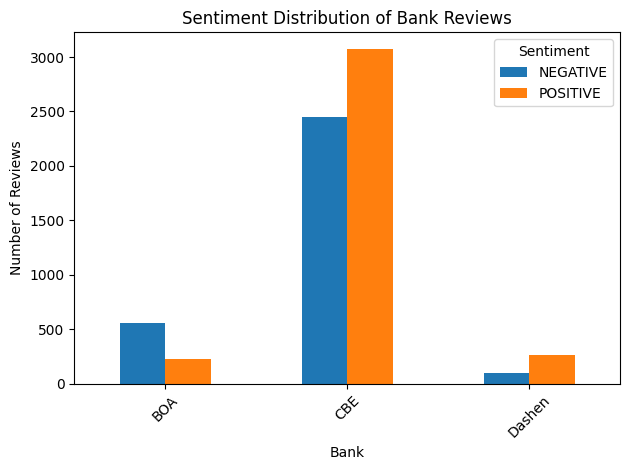

In [30]:
# Set up the plot
plt.figure(figsize=(12, 6))
sentiment_counts.plot(kind='bar', stacked=False, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add titles and labels
plt.title('Sentiment Distribution of Bank Reviews')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

# Show the plot
plt.tight_layout()
plt.savefig('sentiment_distribution_all_banks.png')  # Save the plot as a PNG file
plt.show()

In [31]:
from collections import Counter
nlp = spacy.load("en_core_web_sm")
def extract_keywords(reviews):
    keywords = []
    for review in reviews:
        doc = nlp(review)
        keywords.extend([token.lemma_ for token in doc if token.is_alpha and not token.is_stop])
    return keywords
keywords = extract_keywords(df['review'].tolist())
keyword_counts = Counter(keywords)
top_keywords = keyword_counts.most_common(10)
print(top_keywords)

[('app', 2436), ('good', 1213), ('work', 720), ('use', 563), ('update', 517), ('bank', 503), ('transaction', 447), ('easy', 423), ('time', 375), ('application', 363)]


/tmp/ipykernel_9320/8952442.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x='Keyword', y='Count', palette='viridis')


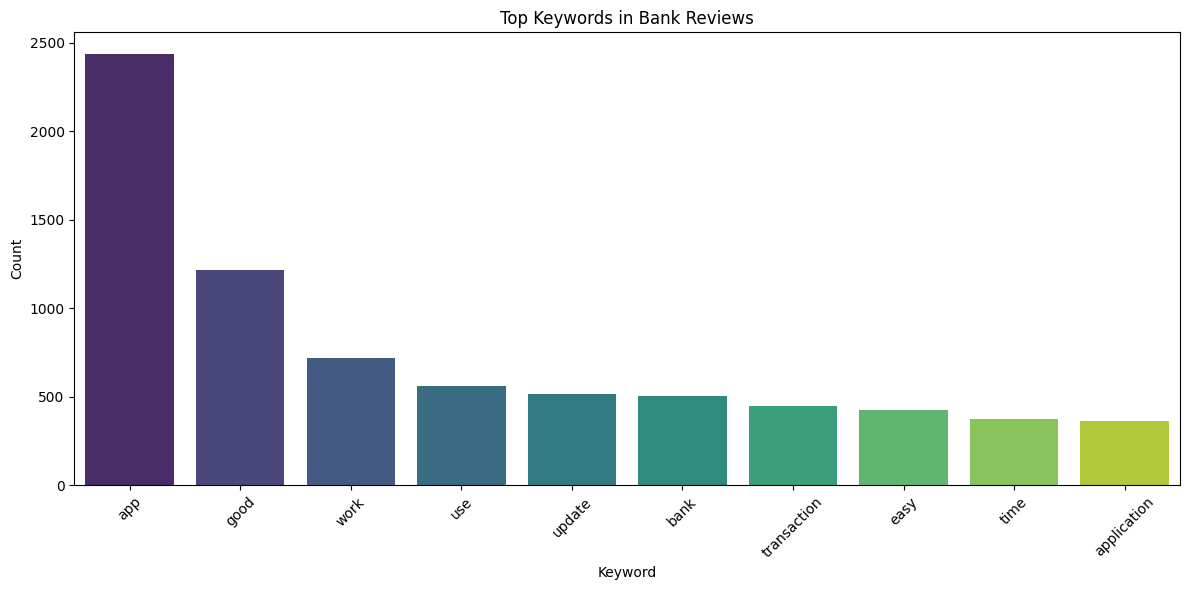

In [32]:
# Create a DataFrame for top keywords
keywords_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Count'])  
# Plot top keywords
plt.figure(figsize=(12, 6))
sns.barplot(data=keywords_df, x='Keyword', y='Count', palette='viridis')
plt.title('Top Keywords in Bank Reviews')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_keywords.png')  # Save the plot as a PNG file
plt.show()

In [33]:
keywords_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Count'])
keywords_df

,Keyword,Count
0,app,2436
1,good,1213
2,work,720
3,use,563
4,update,517
5,bank,503
6,transaction,447
7,easy,423
8,time,375
9,application,363


In [38]:
# Group keywords into themes (example grouping)
themes = {
    'Account Access Issues': ['login', 'error', 'access'],
    'Transaction Performance': ['transfer', 'slow', 'delay'],
    'User Interface & Experience': ['UI', 'design', 'navigate'],
    'Customer Support': ['support', 'help', 'assistance'],
    'Feature Requests': ['feature', 'suggestion', 'request']
}

# Function to assign themes
def assign_theme(review):
    for theme, keywords in themes.items():
        if any(keyword in review for keyword in keywords):
            return theme
    return 'Other'

# Assign themes to reviews
df['identified_theme'] = df['review'].apply(assign_theme)

# Save results
df.to_csv('bank_reviews_with_sentiment_and_themes.csv', index=False)
df

,review,rating,date,bank,source,sentiment,identified_theme
0,what is this app problem???,1,2025-06-05,CBE,Google Play Store,NEGATIVE,Other
1,the app is proactive and a good connections.,5,2025-06-05,CBE,Google Play Store,POSITIVE,Other
2,I cannot send to cbebirr app. through this app.,3,2025-06-05,CBE,Google Play Store,NEGATIVE,Other
3,good,4,2025-06-05,CBE,Google Play Store,POSITIVE,Other
4,not functional,1,2025-06-05,CBE,Google Play Store,NEGATIVE,Other
...,...,...,...,...,...,...,...
6664,Faster and userfriendly,5,2025-01-14,Dashen,Google Play Store,POSITIVE,Other
6665,"Waw Great and innovated,user friendly, always ...",5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other
6666,It's Best waww 🙏,5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other
6667,Always one step ahead,5,2025-01-13,Dashen,Google Play Store,POSITIVE,Other


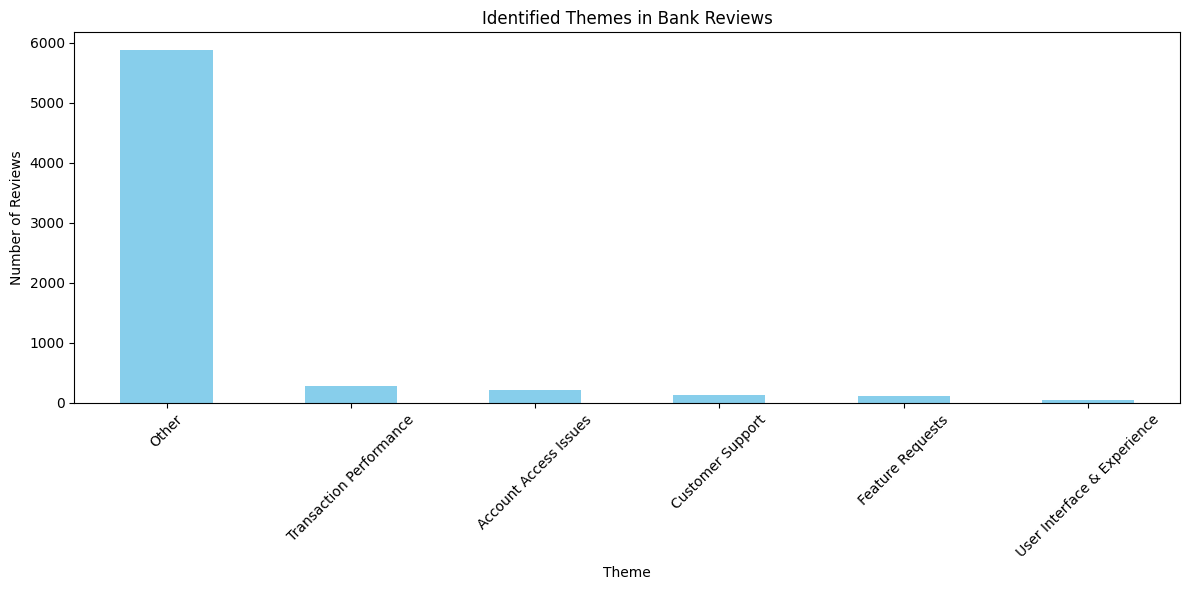

In [ ]:
df['identified_theme'].value_counts().plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Identified Themes in Bank Reviews')
plt.xlabel('Theme')
plt.ylabel('Number of Reviews')             
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('identified_themes.png')  
plt.show()